In [1]:
from torchvision import models
from torchvision.models import vit_b_16

print("=" * 60)

try:
    m1 = models.resnet50(weights=None)
    print("ResNet50 build success")
except Exception as e:
    print("Fail", e)

try:
    m2 = vit_b_16(weights=None)
    print("Vit-B/16 build success")
except Exception as e:
    print("Fail",e)

print("=" * 60)

ResNet50 build success
Vit-B/16 build success


In [26]:
# 1. Import & Settings
import os
import gc
import random
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, roc_auc_score, recall_score,
    roc_curve, ConfusionMatrixDisplay
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import vit_b_16, ViT_B_16_Weights, ResNet50_Weights

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

torch.backends.cudnn.benchmark = True

Device: cuda


In [3]:
print(f"현재 작업 경로: {os.getcwd()}")

test_relative = '/tf/nasw/dataset001/preprocessed/npz/fold_1_train.npz'
print(f"상대경로: {os.path.exists(test_relative)}")

현재 작업 경로: /tf/notebooks/Image Encoder/Untitled Folder
상대경로: False


In [27]:
#2. Hyperparameters & Paths
DATA_ROOT = Path("/tf/nasw/dataset001/preprocessed/npz_ct")

FOLDS = [1, 2, 3, 4, 5]

OUTPUT_DIR = Path("./ct_binary_models")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FIGURE_DIR = Path("./ct_binary_figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 8
NUM_WORKERS = 2
NUM_EPOCHS = 30
LR = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 7

print("DATA_ROOT:", DATA_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())
print("FIGURE_DIR:", FIGURE_DIR.resolve())
print("FOLDS:", FOLDS)

DATA_ROOT: /tf/nasw/dataset001/preprocessed/npz_ct
OUTPUT_DIR: /tf/notebooks/Image Encoder/Untitled Folder/ct_binary_models
FIGURE_DIR: /tf/notebooks/Image Encoder/Untitled Folder/ct_binary_figures
FOLDS: [1, 2, 3, 4, 5]


In [5]:
def inspect_fold_npz(fold_idx):
    train_npz_path = DATA_ROOT / f"fold_{fold_idx}_train.npz"
    val_npz_path = DATA_ROOT / f"fold_{fold_idx}_val.npz"

    print("TRAIN:", train_npz_path, train_npz_path.exits())
    print("VAL:", val_npz_path, val_npz_path.exists())

    train_npz = np.load(train_npz_path, allow_pickle=False, mmap_mode="r")
    val_npz = np.load(val_npz_path, allow_pickle=False, mmap_mode="r")

    for k in train_npz.files:
        print(f"[train] {k}: shape={train_npz[k].shape}, dtype={train_npz[k].dtype}")
    for k in val_npz.files:
        print(f"[val] {k}: shape={val_npz[k].shape}, dtype={val_npz[k].dtype}")

In [28]:
# local pretrained weight paths
LOCAL_RESNET18_IMAGENET_WEIGHTS = Path("/tf/pretrained_model/resnet18-f37072fd.pth")
LOCAL_RESNET50_IMAGENET_WEIGHTS = Path("/tf/pretrained_model/resnet50-11ad3fa6.pth")
LOCAL_RESNET18_RADIMAGENET_WEIGHTS = Path("/tf/pretrained_model/RadImageNet_resnet18.pth")
LOCAL_RESNET50_RADIMAGENET_WEIGHTS = Path("/tf/pretrained_model/RadImageNet_resnet50.pth")
LOCAL_VIT_WEIGHTS = Path("/tf/pretrained_model/vit_b_16-c867db91.pth")

print("LOCAL_RESNET18_IMAGENET_WEIGHTS exists:", LOCAL_RESNET18_IMAGENET_WEIGHTS.exists())
print("LOCAL_RESNET50_IMAGENET_WEIGHTS exists:", LOCAL_RESNET50_IMAGENET_WEIGHTS.exists())
print("LOCAL_RESNET18_RADIMAGENET_WEIGHTS exists:", LOCAL_RESNET18_RADIMAGENET_WEIGHTS.exists())
print("LOCAL_RESNET50_RADIMAGENET_WEIGHTS exists:", LOCAL_RESNET50_RADIMAGENET_WEIGHTS.exists())
print("LOCAL_VIT_WEIGHTS exists:", LOCAL_VIT_WEIGHTS.exists())

LOCAL_RESNET18_IMAGENET_WEIGHTS exists: True
LOCAL_RESNET50_IMAGENET_WEIGHTS exists: True
LOCAL_RESNET18_RADIMAGENET_WEIGHTS exists: True
LOCAL_RESNET50_RADIMAGENET_WEIGHTS exists: True
LOCAL_VIT_WEIGHTS exists: True


In [7]:
def load_local_state_dict(weight_path):
    weight_path = Path(weight_path)
    assert weight_path.exists(), f"Weight file not found: {weight_path}"

    ckpt = torch.load(weight_path, map_location="cpu")

    if isinstance(ckpt, dict) and "state_dict" in ckpt and isinstance(ckpt["state_dict"], dict):
        ckpt = ckpt["state_dict"]

    return ckpt

In [33]:
# 3. Dataset

NORM_STATS = {
    "imagenet": {"mean": [0.485, 0.456, 0.406], "std": [0.229, 0.224, 0.225]},
    "radimagenet": {"mean": [0.204, 0.204, 0.204], "std": [0.286, 0.286, 0.286]}
}

class OvarianCTNPZDataset(Dataset):
    def __init__(self, npz_path, norm_type="imagenet"):
        super().__init__()
        assert norm_type in NORM_STATS, f"norm_type must be one of {list(NORM_STATS.keys())}"
        
        self.npz = np.load(npz_path, allow_pickle=False, mmap_mode="r")

        self.images = self.npz["images"]
        self.labels = self.npz["labels"].astype(np.float32)

        stats = NORM_STATS[norm_type]
        self.mean = torch.tensor(stats["mean"], dtype=torch.float32).view(1, 3, 1, 1)
        self.std = torch.tensor(stats["std"], dtype=torch.float32).view(1, 3, 1, 1)

        self.tumor_types = self.npz["tumor_types"] if "tumor_types" in self.npz.files else None
        self.recurrences = self.npz["recurrences"] if "recurrences" in self.npz.files else None

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = self.images[idx]
        y = self.labels[idx]

        x = torch.from_numpy(x).float().permute(0, 3, 1, 2).contiguous()

        x = x / 255.0
        x = (x-self.mean) / self.std

        y = torch.tensor([y], dtype=torch.float32)

        return x, y

In [34]:
# 4. fold별 dataLoader 생성
def make_fold_loaders(fold_idx, norm_type="imagenet"):
    train_npz_path = DATA_ROOT / f"fold_{fold_idx}_train.npz"
    val_npz_path = DATA_ROOT / f"fold_{fold_idx}_val.npz"

    assert train_npz_path.exists(), f"Missing: {train_npz_path}"
    assert val_npz_path.exists(), f"Missing: {val_npz_path}"

    train_dataset = OvarianCTNPZDataset(train_npz_path, norm_type=norm_type)
    val_dataset = OvarianCTNPZDataset(val_npz_path, norm_type=norm_type)

    train_loader = DataLoader(
        train_dataset,
        batch_size = BATCH_SIZE,
        shuffle = True,
        num_workers = NUM_WORKERS,
        pin_memory = True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size = BATCH_SIZE,
        shuffle = False,
        num_workers = NUM_WORKERS,
        pin_memory = True
    )

    labels_np = train_dataset.labels.astype(int)
    neg = (labels_np == 0).sum()
    pos = (labels_np == 1).sum()

    pos_weight_value = neg / max(pos, 1)
    pos_weight = torch.tensor([pos_weight_value], device = device, dtype = torch.float32)

    print(f"[FOLD {fold_idx}] Train benign(0): {neg}, malignant(1): {pos}, pos_weight={pos_weight.item():.4f}")

    return train_loader, val_loader, pos_weight

In [35]:
# 5. train/eval 함수

scaler = torch.amp.GradScaler(enabled=(device.type == "cuda"))

def compute_binary_metrics(y_true, y_prob, threshold = 0.5):
    y_true = np.array(y_true).astype(int)
    y_prob = np.array(y_prob).astype(float)
    y_pred = (y_prob > threshold).astype(int)

    metrics = {
        "acc": accuracy_score(y_true, y_pred),
        "auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0.5,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "cm": confusion_matrix(y_true, y_pred)
    }
    return metrics

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    y_true, y_prob = [], []

    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type="cuda", enabled=(device.type == "cuda")):
            logits = model(imgs)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * imgs.size(0)

        probs = torch.sigmoid(logits)
        y_true.extend(labels.detach().cpu().numpy().ravel())
        y_prob.extend(probs.detach().cpu().numpy().ravel())

    metric_vals = compute_binary_metrics(y_true, y_prob, threshold = 0.5)

    metrics = {
        "loss": running_loss / len(loader.dataset),
        "acc": metric_vals["acc"],
        "auc": metric_vals["auc"],
        "f1": metric_vals["f1"],
        "recall": metric_vals["recall"],
        "cm": metric_vals["cm"]
    }
    return metrics

@torch.no_grad()
def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    y_true, y_prob = [], []

    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking = True)
        labels = labels.to(device, non_blocking = True)

        with torch.amp.autocast(device_type="cuda", enabled=(device.type == "cuda")):
            logits = model(imgs)
            loss = criterion(logits, labels)

        running_loss += loss.item() * imgs.size(0)

        probs = torch.sigmoid(logits)
        y_true.extend(labels.detach().cpu().numpy().ravel())
        y_prob.extend(probs.detach().cpu().numpy().ravel())

    metric_vals = compute_binary_metrics(y_true, y_prob, threshold = 0.5)

    metrics = {
        "loss": running_loss / len(loader.dataset),
        "auc": metric_vals["auc"],
        "acc": metric_vals["acc"],
        "f1": metric_vals["f1"],
        "recall": metric_vals["recall"],
        "cm": metric_vals["cm"]
    }
    return metrics

@torch.no_grad()
def eval_confusion(model, loader, device, threshold = 0.5):
    model.eval()
    y_true, y_prob = [], []

    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking = True)
        labels = labels.to(device, non_blocking = True)

        logits = model(imgs)
        probs = torch.sigmoid(logits)

        y_true.extend(labels.cpu().numpy().ravel())
        y_prob.extend(probs.cpu().numpy().ravel())

    metric_vals = compute_binary_metrics(y_true, y_prob, threshold = 0.5)

    print(f"\n--Final Evaluation (threshold={threshold}) --")
    print(f"Accuracy: {metric_vals['acc']:.4f}")
    print(f"ROC-AUC : {metric_vals['auc']:.4f}")
    print(f"F1-score : {metric_vals['f1']:.4f}")
    print(f"Sensitivity : {metric_vals['recall']:.4f}")
    print("Confusion Matrix:")
    print(metric_vals["cm"])

    print("\nClassification report:")
    y_pred = (np.array(y_prob) > threshold).astype(int)
    print(classification_report(np.array(y_true).astype(int), y_pred, digits = 4, zero_division = 0))

    metric_vals["y_true"] = np.array(y_true).astype(int)
    metric_vals["y_prob"] = np.array(y_prob).astype(float)

    return metric_vals
        

In [36]:
# 6. slice encoder + patient-level pooling wrapper

class PatientSliceAttentionClassifier(nn.Module):
    def __init__(self, encoder, feat_dim, hidden_dim=512, dropout=0.3):
        super().__init__()
        self.encoder = encoder

        self.attn = nn.Sequential(
            nn.Linear(feat_dim, feat_dim // 2),
            nn.Tanh(),
            nn.Linear(feat_dim // 2, 1)
        )

        self.classifier = nn.Sequential(
            nn.Linear(feat_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        # x: (B, S, C, H, W)
        B, S, C, H, W = x.shape
        x = x.view(B * S, C, H, W)

        feat = self.encoder(x)
        feat = feat.view(B, S, -1)

        attn_score = self.attn(feat)
        attn_weight = torch.softmax(attn_score, dim=1)

        pooled = (feat * attn_weight).sum(dim=1)
        logits = self.classifier(pooled)

        return logits

In [38]:
# 7. model define
def build_resnet18_patient_model(load_pretrained=True, freeze_backbone=True, 
                                 unfreeze_layer4=True, 
                                 weight_path=LOCAL_RESNET18_IMAGENET_WEIGHTS):
    encoder = models.resnet18(weights=None)

    if load_pretrained:
        state_dict = load_local_state_dict(weight_path)
        encoder.load_state_dict(state_dict, strict = True)
        
    feat_dim = encoder.fc.in_features
    encoder.fc = nn.Identity()

    if freeze_backbone:
        for p in encoder.parameters():
            p.requires_grad = False

        if unfreeze_layer4:
            for p in encoder.layer4.parameters():
                p.requires_grad = True
    
    model = PatientSliceAttentionClassifier(
        encoder = encoder,
        feat_dim = feat_dim,
        hidden_dim = 256,
        dropout=0.1
    )
    
    return model
    
def build_resnet50_patient_model(load_pretrained=True, freeze_backbone=True, 
                                 unfreeze_layer4=True, 
                                 weight_path=LOCAL_RESNET50_IMAGENET_WEIGHTS):
    encoder = models.resnet50(weights=None)

    if load_pretrained:
        state_dict = load_local_state_dict(weight_path)
        encoder.load_state_dict(state_dict, strict = True)
        
    feat_dim = encoder.fc.in_features
    encoder.fc = nn.Identity()

    if freeze_backbone:
        for p in encoder.parameters():
            p.requires_grad = False

        if unfreeze_layer4:
            for p in encoder.layer4.parameters():
                p.requires_grad = True
    
    model = PatientSliceAttentionClassifier(
        encoder = encoder,
        feat_dim = feat_dim,
        hidden_dim = 512,
        dropout=0.1
    )
    
    return model

def _load_radimagenet_weights(resnet_model, weight_path):
    ckpt = torch.load(path, map_location="cpu", weights_only=False)

    if isinstance(ckpt, dict):
        if "model" in ckpt:
            state = ckpt["model"]
        elif "state_dict" in ckpt:
            state = ckpt["state_dict"]
        else:
            state = ckpt

    else:
        raise ValueError(f"Unexpected checkpoint type: {type(ckpt)}")

    # _orig_mod. prefix 제거
    state = {k.replace("_orig_mod.", ""): v 
             for k, v in state.items()
            }

    # fc layer 제외
    state = {k: v for k, v in state.items() if not k.startswith("fc.")}

    missing, unexpected = model.load_state_dict(state, strict=False)
    print(f"  [RadImageNet] loaded {path.name}")
    if missing:
        print(f"   missing keys ({len(missing)}): {missing[:3]}{'...' if len(missing) > 3 else ''}")
    if unexpected:
        print(f"   unexpected keys ({len(unexpected)}): {unexpected[:3]}{'...' if len(unexpected) > 3 else ''}")

    return model

def build_resnet18_radimagenet_patient_model(load_pretrained=True, freeze_backbone=True, 
                                             unfreeze_layer4=True, 
                                             weight_path=LOCAL_RESNET18_RADIMAGENET_WEIGHTS):
    encoder = models.resnet18(weights=None)

    if load_pretrained:
        state_dict = load_local_state_dict(weight_path)
        encoder.load_state_dict(state_dict, strict = True)
        
    feat_dim = encoder.fc.in_features
    encoder.fc = nn.Identity()

    if freeze_backbone:
        for p in encoder.parameters():
            p.requires_grad = False

        if unfreeze_layer4:
            for p in encoder.layer4.parameters():
                p.requires_grad = True
    
    model = PatientSliceAttentionClassifier(
        encoder = encoder,
        feat_dim = feat_dim,
        hidden_dim = 256,
        dropout=0.1
    )
    
    return model

def build_resnet50_radimagenet_patient_model(load_pretrained=True, freeze_backbone=True, 
                                             unfreeze_layer4=True, 
                                             weight_path=LOCAL_RESNET50_RADIMAGENET_WEIGHTS):
    encoder = models.resnet50(weights=None)

    if load_pretrained:
        state_dict = load_local_state_dict(weight_path)
        encoder.load_state_dict(state_dict, strict = True)
        
    feat_dim = encoder.fc.in_features
    encoder.fc = nn.Identity()

    if freeze_backbone:
        for p in encoder.parameters():
            p.requires_grad = False

        if unfreeze_layer4:
            for p in encoder.layer4.parameters():
                p.requires_grad = True
    
    model = PatientSliceAttentionClassifier(
        encoder = encoder,
        feat_dim = feat_dim,
        hidden_dim = 512,
        dropout=0.1
    )
    
    return model

    
def build_vit_patient_model(load_pretrained=True, weight_path=LOCAL_VIT_WEIGHTS,
                            freeze_backbone=True, unfreeze_last_n_blocks=2):
    encoder = vit_b_16(weights=None)
    if load_pretrained:
        state_dict = load_local_state_dict(weight_path)
        encoder.load_state_dict(state_dict, strict = True)
    
    feat_dim = encoder.heads.head.in_features
    encoder.heads = nn.Identity()

    if freeze_backbone:
        for p in encoder.parameters():
            p.requires_grad = False
        for block in encoder.encoder.layers[-unfreeze_last_n_blocks:]:
            for p in block.parameters():
                p.requires_grad = True
        for p in encoder.encoder.ln.parameters():
            p.requires_grad = True

    
    model = PatientSliceAttentionClassifier(
        encoder = encoder,
        feat_dim = feat_dim,
        hidden_dim = 512,
        dropout=0.3
    )
    return model

class CNNTransformerHybridPatient(nn.Module):
    def __init__(self,backbone_builder, d_model=512, nhead=8, num_layers=2, 
                 dim_feedforward=1024, dropout=0.3, 
                 load_pretrained=True, freeze_backbone=True, unfreeze_layer4=True, 
                 resnet_weight_path=LOCAL_RESNET50_IMAGENET_WEIGHTS):
        super().__init__()

        if backbone_builder == "resnet18_imagenet":
            backbone = models.resnet18(weights=None)
            if load_pretrained:
                state_dict = load_local_state_dict(resnet_weight_path)
                backbone.load_state_dict(state_dict, strict = True)
            feat_dim = backbone.fc.in_features
        
        elif backbone_builder == "resnet50_imagenet":
            backbone = models.resnet50(weights=None)
            if load_pretrained:
                state_dict = load_local_state_dict(resnet_weight_path)
                backbone.load_state_dict(state_dict, strict = True)
            feat_dim = backbone.fc.in_features

        elif backbone_builder == "resnet18_radimagenet":
            backbone = models.resnet18(weights=None)
            if load_pretrained:
                backbone = load_radimagent_resnet(backbone, resnet_weight_path)
            feat_dim = backbone.fc.in_features
            
        elif backbone_builder == "resnet50_radimagenet":
            backbone = models.resnet50(weights=None)
            if load_pretrained:
                backbone = load_radimagent_resnet(backbone, resnet_weight_path)
            feat_dim = backbone.fc.in_features

        else:
            raise ValueError(f"Unknown backbone_builder: {backbone_builder}")

        backbone.fc = nn.Identity()
        self.encoder = backbone
        
        if freeze_backbone:
            for p in self.encoder.parameters():
                p.requires_grad = False

            if unfreeze_layer4:
                for p in self.encoder.layer4.parameters():
                    p.requires_grad = True

        self.proj = nn.Linear(feat_dim, d_model)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.zeros(1, 1+8, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=0.1,
            batch_first=True,
            activation="gelu"
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers= num_layers)
        self.norm = nn.LayerNorm(d_model)

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 1)
        )

    def forward(self, x):
        B, S, C, H, W = x.shape
        x = x.view(B * S, C, H, W)

        feat = self.encoder(x)
        feat = feat.view(B, S, -1)
        feat = self.proj(feat)

        cls = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls, feat], dim=1)
        tokens = tokens + self.pos_embed[:, :tokens.size(1), :]

        tokens = self.transformer(tokens)
        tokens = self.norm(tokens)

        cls_out = tokens[:, 0, :]
        logits = self.classifier(cls_out)

        return logits

        

def build_hybrid_patient_model(load_pretrained=True):
    return CNNTransformerHybridPatient(
        backbone_builder="resnet50_imagenet",
        load_pretrained=load_pretrained,
        freeze_backbone = True,
        unfreeze_layer4 = True,
        resnet_weight_path=LOCAL_RESNET50_IMAGENET_WEIGHTS
    )

def build_hybrid_r18_patient_model(load_pretrained=True):
    return CNNTransformerHybridPatient(
        backbone_builder="resnet18_imagenet",
        load_pretrained=load_pretrained,
        freeze_backbone = True,
        unfreeze_layer4 = True,
        resnet_weight_path=LOCAL_RESNET18_IMAGENET_WEIGHTS
    )

In [39]:
# 8. 공통 학습 함수
def fit_model(model, model_name, fold_idx, train_loader, val_loader, device, 
              num_epochs=30, lr = 1e-4, weight_decay=1e-4, 
              pos_weight=None, patience = 7, min_delta=0.001):
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight = pos_weight)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr = lr,
        weight_decay = weight_decay
    )

    best_auc = -1
    best_val_loss = np.inf
    best_path = OUTPUT_DIR / f"{model_name}_fold{fold_idx}_best.pth"
    history = []
    early_stop_counter = 0

    for epoch in range(1, num_epochs+1):
        train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_metrics = eval_one_epoch(model, val_loader, criterion, device)

        row = {
            "fold": fold_idx,
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_acc": train_metrics["acc"],
            "train_f1": train_metrics["f1"],
            "train_recall": train_metrics["recall"],
            "train_auc": train_metrics["auc"],
            "val_loss":val_metrics["loss"],
            "val_acc": val_metrics["acc"],
            "val_f1": val_metrics["f1"],
            "val_auc": val_metrics["auc"],
            "val_recall": val_metrics["recall"],
        }
        history.append(row)

        print(
            f"[{model_name}][Fold {fold_idx}][Epoch {epoch:02d}]"
            f"train loss = {row['train_loss']:.4f}, acc={row['train_acc']:.4f}, auc={row['train_auc']:.4f},"
            f"f1 = {row['train_f1']:.4f}, recall={row['train_recall']:.4f} | "
            f"val loss = {row['val_loss']:.4f}, acc = {row['val_acc']:.4f}, auc = {row['val_auc']:.4f}, "
            f"f1 = {row['val_f1']:.4f}, recall={row['val_recall']:.4f}"
        )

        if row["val_auc"] > best_auc:
            best_auc = row["val_auc"]

        if row["val_loss"] < best_val_loss - min_delta:
            best_val_loss = row["val_loss"]
            early_stop_counter = 0
            torch.save(model.state_dict(), best_path)
            print(f"  -> best saved by val_loss: {best_path}")
        else:
            early_stop_counter += 1
            print(f"  -> no improvement ({early_stop_counter}/{patience})")

        if early_stop_counter >= patience:
            print(f"  -> early stopping triggered at epoch {epoch}")
            break

    history_df = pd.DataFrame(history)
    return model, history_df, best_path

In [46]:
# 9. model 로드 함수
def load_model(model_type, model_path, device):
    if model_type == "resnet18_imagenet":
        model = build_resnet18_patient_model(load_pretrained=False)
    elif model_type == "resnet50_imagenet":
        model = build_resnet50_patient_model(load_pretrained=False)
    elif model_type == "resnet18_radimagenet":
        model = build_resnet18_radimagenet_patient_model(load_pretrained=False)
    elif model_type == "resnet50_radimagenet":
        model = build_resnet50_radimagenet_patient_model(load_pretrained=False)
    elif model_type == "vit":
        model = build_vit_patient_model(load_pretrained=False)
    elif model_type == "hybrid_r50":
        model = build_hybrid_patient_model(load_pretrained=False)
    elif model_type == "hybrid_r18":
        model = build_hybrid_r18_patient_model(load_pretrained=False)
    else:
        raise ValueError(f"Unknown model type: {model_type}")

    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    return model

In [41]:
# 10. 5-Fold CV
def run_cv_for_model(model_name, model_type, build_fn, norm_type="imagenet", lr=None):
    fold_results = []
    fold_histories = []
    effective_lr = lr if lr is not None else LR

    for fold_idx in FOLDS:
        print("\n" + "=" * 80)
        print(f"Running {model_name} | Fold {fold_idx} | norm={norm_type}")
        print("=" * 80)

        train_loader, val_loader, pos_weight = make_fold_loaders(fold_idx, norm_type=norm_type)

        model = build_fn()

        _, history_df, best_path = fit_model(
            model=model,
            model_name=model_name,
            fold_idx = fold_idx,
            train_loader=train_loader,
            val_loader=val_loader,
            device=device,
            num_epochs=NUM_EPOCHS,
            lr=effective_lr,
            weight_decay=WEIGHT_DECAY,
            pos_weight=pos_weight,
            patience=PATIENCE
            
        )

        best_model = load_model(model_type, best_path, device)
        final_metrics = eval_confusion(best_model, val_loader, device, threshold=0.5)

        print(f"\n[{model_name}][Fold {fold_idx}] Final Metrics")
        print(f"Accuracy: {final_metrics['acc']:.4f}")
        print(f"ROC-AUC: {final_metrics['auc']:.4f}")
        print(f"F1-score : {final_metrics['f1']:.4f}")
        print(f"Sensitivity : {final_metrics['recall']:.4f}")
        print("Confusion Matrix:")
        print(final_metrics["cm"])

        fold_results.append({
            "model": model_name,
            "fold": fold_idx,
            "acc": final_metrics["acc"],
            "ROC-AUC": final_metrics["auc"],
            "F1-score": final_metrics["f1"],
            "Sensitivity": final_metrics["recall"],
            "Confusion Matrix": final_metrics["cm"]
        })

        history_df["model"] = model_name
        fold_histories.append(history_df)

        del model
        del best_model
        del train_loader
        del val_loader
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            
    result_df = pd.DataFrame(fold_results)
    history_df_all = pd.concat(fold_histories, ignore_index=True)
    return result_df, history_df_all

In [20]:
print(">>> Training ResNet18 (ImageNet)...")
resnet18_imagenet_cv_df, resnet18_imagenet_history_df = run_cv_for_model(
    model_name="ResNet18_ImageNet",
    model_type="resnet18_imagenet",
    build_fn=lambda: build_resnet18_patient_model(load_pretrained=True),
    norm_type="imagenet"
)
display(resnet18_imagenet_cv_df)

>>> Training ResNet18 (ImageNet)...

Running ResNet18_ImageNet | Fold 1 | norm=imagenet
[FOLD 1] Train benign(0): 1605, malignant(1): 444, pos_weight=3.6149
[ResNet18_ImageNet][Fold 1][Epoch 01]train loss = 0.6143, acc=0.8365, auc=0.9053,f1 = 0.6890, recall=0.8356 | val loss = 0.3248, acc = 0.9318, auc = 0.9765, f1 = 0.8571, recall=0.9459
  -> best saved by val_loss: ct_binary_models/ResNet18_ImageNet_fold1_best.pth
[ResNet18_ImageNet][Fold 1][Epoch 02]train loss = 0.4120, acc=0.8956, auc=0.9583,f1 = 0.7902, recall=0.9077 | val loss = 0.3168, acc = 0.9201, auc = 0.9752, f1 = 0.8353, recall=0.9369
  -> best saved by val_loss: ct_binary_models/ResNet18_ImageNet_fold1_best.pth
[ResNet18_ImageNet][Fold 1][Epoch 03]train loss = 0.2972, acc=0.9239, auc=0.9780,f1 = 0.8405, recall=0.9257 | val loss = 0.3568, acc = 0.8733, auc = 0.9729, f1 = 0.7687, recall=0.9730
  -> no improvement (1/7)
[ResNet18_ImageNet][Fold 1][Epoch 04]train loss = 0.2184, acc=0.9424, auc=0.9879,f1 = 0.8778, recall=0.9550

,model,fold,acc,ROC-AUC,F1-score,Sensitivity,Confusion Matrix
0,ResNet18_ImageNet,1,0.920078,0.975236,0.835341,0.936937,"[[368, 34], [7, 104]]"
1,ResNet18_ImageNet,2,0.851852,0.939581,0.722628,0.891892,"[[338, 64], [12, 99]]"
2,ResNet18_ImageNet,3,0.896484,0.974074,0.796935,0.936937,"[[355, 46], [7, 104]]"
3,ResNet18_ImageNet,4,0.884766,0.962526,0.773946,0.909910,"[[352, 49], [10, 101]]"
4,ResNet18_ImageNet,5,0.873047,0.961762,0.767025,0.963964,"[[340, 61], [4, 107]]"


In [21]:
print(">>> Training ResNet50 (ImageNet)...")
resnet50_imagenet_cv_df, resnet50_imagenet_history_df = run_cv_for_model(
    model_name="ResNet50_ImageNet",
    model_type="resnet50_imagenet",
    build_fn=lambda: build_resnet50_patient_model(load_pretrained=True),
    norm_type="imagenet"
)
display(resnet50_imagenet_cv_df)

>>> Training ResNet50 (ImageNet)...

Running ResNet50_ImageNet | Fold 1 | norm=imagenet
[FOLD 1] Train benign(0): 1605, malignant(1): 444, pos_weight=3.6149
[ResNet50_ImageNet][Fold 1][Epoch 01]train loss = 0.6759, acc=0.8170, auc=0.8879,f1 = 0.6505, recall=0.7860 | val loss = 0.4407, acc = 0.8655, auc = 0.9565, f1 = 0.7579, recall=0.9730
  -> best saved by val_loss: ct_binary_models/ResNet50_ImageNet_fold1_best.pth
[ResNet50_ImageNet][Fold 1][Epoch 02]train loss = 0.4563, acc=0.8892, auc=0.9489,f1 = 0.7764, recall=0.8874 | val loss = 0.4028, acc = 0.9376, auc = 0.9657, f1 = 0.8609, recall=0.8919
  -> best saved by val_loss: ct_binary_models/ResNet50_ImageNet_fold1_best.pth
[ResNet50_ImageNet][Fold 1][Epoch 03]train loss = 0.2972, acc=0.9268, auc=0.9779,f1 = 0.8454, recall=0.9234 | val loss = 0.2756, acc = 0.9357, auc = 0.9818, f1 = 0.8631, recall=0.9369
  -> best saved by val_loss: ct_binary_models/ResNet50_ImageNet_fold1_best.pth
[ResNet50_ImageNet][Fold 1][Epoch 04]train loss = 0.22

,model,fold,acc,ROC-AUC,F1-score,Sensitivity,Confusion Matrix
0,ResNet50_ImageNet,1,0.935673,0.981825,0.863071,0.936937,"[[376, 26], [7, 104]]"
1,ResNet50_ImageNet,2,0.884990,0.945274,0.768627,0.882883,"[[356, 46], [13, 98]]"
2,ResNet50_ImageNet,3,0.863281,0.967267,0.750000,0.945946,"[[337, 64], [6, 105]]"
3,ResNet50_ImageNet,4,0.908203,0.958595,0.806584,0.882883,"[[367, 34], [13, 98]]"
4,ResNet50_ImageNet,5,0.867188,0.954258,0.751825,0.927928,"[[341, 60], [8, 103]]"


In [22]:
print(">>> Training ResNet18 (RadImageNet)...")
resnet18_rad_cv_df, resnet18_rad_history_df = run_cv_for_model(
    model_name="ResNet18_RadImageNet",
    model_type="resnet18_radimagenet",
    build_fn=lambda: build_resnet18_patient_model(load_pretrained=True),
    norm_type="radimagenet"
)
display(resnet18_rad_cv_df)

>>> Training ResNet18 (RadImageNet)...

Running ResNet18_RadImageNet | Fold 1 | norm=radimagenet
[FOLD 1] Train benign(0): 1605, malignant(1): 444, pos_weight=3.6149
[ResNet18_RadImageNet][Fold 1][Epoch 01]train loss = 0.6439, acc=0.8141, auc=0.8964,f1 = 0.6613, recall=0.8378 | val loss = 0.3035, acc = 0.9123, auc = 0.9816, f1 = 0.8263, recall=0.9640
  -> best saved by val_loss: ct_binary_models/ResNet18_RadImageNet_fold1_best.pth
[ResNet18_RadImageNet][Fold 1][Epoch 02]train loss = 0.3846, acc=0.8907, auc=0.9631,f1 = 0.7850, recall=0.9212 | val loss = 0.2672, acc = 0.9298, auc = 0.9830, f1 = 0.8512, recall=0.9279
  -> best saved by val_loss: ct_binary_models/ResNet18_RadImageNet_fold1_best.pth
[ResNet18_RadImageNet][Fold 1][Epoch 03]train loss = 0.2857, acc=0.9156, auc=0.9795,f1 = 0.8265, recall=0.9279 | val loss = 0.4395, acc = 0.8402, auc = 0.9546, f1 = 0.7172, recall=0.9369
  -> no improvement (1/7)
[ResNet18_RadImageNet][Fold 1][Epoch 04]train loss = 0.2128, acc=0.9405, auc=0.9885

,model,fold,acc,ROC-AUC,F1-score,Sensitivity,Confusion Matrix
0,ResNet18_RadImageNet,1,0.929825,0.983058,0.851240,0.927928,"[[374, 28], [8, 103]]"
1,ResNet18_RadImageNet,2,0.881092,0.947291,0.764479,0.891892,"[[353, 49], [12, 99]]"
2,ResNet18_RadImageNet,3,0.906250,0.966053,0.806452,0.900901,"[[364, 37], [11, 100]]"
3,ResNet18_RadImageNet,4,0.910156,0.964368,0.806723,0.864865,"[[370, 31], [15, 96]]"
4,ResNet18_RadImageNet,5,0.873047,0.935432,0.750958,0.882883,"[[349, 52], [13, 98]]"


In [23]:
print(">>> Training ResNet50 (RadImageNet)...")
resnet50_rad_cv_df, resnet50_rad_history_df = run_cv_for_model(
    model_name="ResNet50_RadImageNet",
    model_type="resnet50_radimagenet",
    build_fn=lambda: build_resnet50_patient_model(load_pretrained=True),
    norm_type="radimagenet"
)
display(resnet50_rad_cv_df)

>>> Training ResNet50 (RadImageNet)...

Running ResNet50_RadImageNet | Fold 1 | norm=radimagenet
[FOLD 1] Train benign(0): 1605, malignant(1): 444, pos_weight=3.6149
[ResNet50_RadImageNet][Fold 1][Epoch 01]train loss = 0.6769, acc=0.8282, auc=0.8872,f1 = 0.6648, recall=0.7860 | val loss = 0.3406, acc = 0.9064, auc = 0.9781, f1 = 0.8154, recall=0.9550
  -> best saved by val_loss: ct_binary_models/ResNet50_RadImageNet_fold1_best.pth
[ResNet50_RadImageNet][Fold 1][Epoch 02]train loss = 0.4554, acc=0.8838, auc=0.9494,f1 = 0.7676, recall=0.8851 | val loss = 0.4554, acc = 0.9454, auc = 0.9657, f1 = 0.8654, recall=0.8108
  -> no improvement (1/7)
[ResNet50_RadImageNet][Fold 1][Epoch 03]train loss = 0.3141, acc=0.9209, auc=0.9756,f1 = 0.8364, recall=0.9324 | val loss = 0.2818, acc = 0.9415, auc = 0.9835, f1 = 0.8718, recall=0.9189
  -> best saved by val_loss: ct_binary_models/ResNet50_RadImageNet_fold1_best.pth
[ResNet50_RadImageNet][Fold 1][Epoch 04]train loss = 0.2223, acc=0.9492, auc=0.9875

,model,fold,acc,ROC-AUC,F1-score,Sensitivity,Confusion Matrix
0,ResNet50_RadImageNet,1,0.941520,0.983483,0.871795,0.918919,"[[381, 21], [9, 102]]"
1,ResNet50_RadImageNet,2,0.906433,0.947380,0.794872,0.837838,"[[372, 30], [18, 93]]"
2,ResNet50_RadImageNet,3,0.875000,0.960504,0.757576,0.900901,"[[348, 53], [11, 100]]"
3,ResNet50_RadImageNet,4,0.898438,0.967289,0.788618,0.873874,"[[363, 38], [14, 97]]"
4,ResNet50_RadImageNet,5,0.873047,0.960953,0.763636,0.945946,"[[342, 59], [6, 105]]"


In [42]:
print(">>> Training VIT-B/16 (ImageNet)...")
vit_cv_df, vit_history_df = run_cv_for_model(
    model_name="ViT-B16",
    model_type="vit",
    build_fn=lambda: build_vit_patient_model(load_pretrained=True,
                                             freeze_backbone=True,
                                             unfreeze_last_n_blocks=2),
    norm_type="imagenet",
    lr=1e-5
)

display(vit_cv_df)

>>> Training VIT-B/16 (ImageNet)...

Running ViT-B16 | Fold 1 | norm=imagenet
[FOLD 1] Train benign(0): 1605, malignant(1): 444, pos_weight=3.6149
[ViT-B16][Fold 1][Epoch 01]train loss = 0.7488, acc=0.8306, auc=0.8855,f1 = 0.6628, recall=0.7680 | val loss = 0.5326, acc = 0.8070, auc = 0.9534, f1 = 0.6837, recall=0.9640
  -> best saved by val_loss: ct_binary_models/ViT-B16_fold1_best.pth
[ViT-B16][Fold 1][Epoch 02]train loss = 0.4949, acc=0.8760, auc=0.9420,f1 = 0.7544, recall=0.8784 | val loss = 0.4522, acc = 0.8577, auc = 0.9592, f1 = 0.7439, recall=0.9550
  -> best saved by val_loss: ct_binary_models/ViT-B16_fold1_best.pth
[ViT-B16][Fold 1][Epoch 03]train loss = 0.4011, acc=0.8995, auc=0.9612,f1 = 0.7952, recall=0.9009 | val loss = 0.3879, acc = 0.9045, auc = 0.9652, f1 = 0.8016, recall=0.8919
  -> best saved by val_loss: ct_binary_models/ViT-B16_fold1_best.pth
[ViT-B16][Fold 1][Epoch 04]train loss = 0.3501, acc=0.9053, auc=0.9714,f1 = 0.8075, recall=0.9167 | val loss = 0.3642, acc =

,model,fold,acc,ROC-AUC,F1-score,Sensitivity,Confusion Matrix
0,ViT-B16,1,0.906433,0.968334,0.806452,0.900901,"[[365, 37], [11, 100]]"
1,ViT-B16,2,0.871345,0.937139,0.738095,0.837838,"[[354, 48], [18, 93]]"
2,ViT-B16,3,0.916016,0.967716,0.821577,0.891892,"[[370, 31], [12, 99]]"
3,ViT-B16,4,0.882812,0.947361,0.763780,0.873874,"[[355, 46], [14, 97]]"
4,ViT-B16,5,0.884766,0.961425,0.777358,0.927928,"[[350, 51], [8, 103]]"


In [43]:
print(">>> Training Hybrid (ResNet18+ViT)... ")
hybrid_r18_cv_df, hybrid_r18_history_df = run_cv_for_model(
    model_name="Hybrid_R18",
    model_type="hybrid_r18",
    build_fn=lambda: build_hybrid_r18_patient_model(load_pretrained=True),
    norm_type="imagenet"
)

display(hybrid_r18_cv_df)

>>> Training Hybrid (ResNet18+ViT)... 

Running Hybrid_R18 | Fold 1 | norm=imagenet
[FOLD 1] Train benign(0): 1605, malignant(1): 444, pos_weight=3.6149
[Hybrid_R18][Fold 1][Epoch 01]train loss = 0.6348, acc=0.8399, auc=0.8969,f1 = 0.6846, recall=0.8018 | val loss = 0.4465, acc = 0.9279, auc = 0.9759, f1 = 0.8230, recall=0.7748
  -> best saved by val_loss: ct_binary_models/Hybrid_R18_fold1_best.pth
[Hybrid_R18][Fold 1][Epoch 02]train loss = 0.4736, acc=0.8799, auc=0.9425,f1 = 0.7593, recall=0.8739 | val loss = 0.4087, acc = 0.9123, auc = 0.9658, f1 = 0.8163, recall=0.9009
  -> best saved by val_loss: ct_binary_models/Hybrid_R18_fold1_best.pth
[Hybrid_R18][Fold 1][Epoch 03]train loss = 0.3588, acc=0.9214, auc=0.9647,f1 = 0.8359, recall=0.9234 | val loss = 0.4185, acc = 0.8811, auc = 0.9774, f1 = 0.7782, recall=0.9640
  -> no improvement (1/7)
[Hybrid_R18][Fold 1][Epoch 04]train loss = 0.3766, acc=0.9180, auc=0.9622,f1 = 0.8275, recall=0.9077 | val loss = 0.3700, acc = 0.8928, auc = 0.97

,model,fold,acc,ROC-AUC,F1-score,Sensitivity,Confusion Matrix
0,Hybrid_R18,1,0.918129,0.979898,0.832000,0.936937,"[[367, 35], [7, 104]]"
1,Hybrid_R18,2,0.851852,0.931334,0.716418,0.864865,"[[341, 61], [15, 96]]"
2,Hybrid_R18,3,0.867188,0.968075,0.758865,0.963964,"[[337, 64], [4, 107]]"
3,Hybrid_R18,4,0.912109,0.964368,0.814815,0.891892,"[[368, 33], [12, 99]]"
4,Hybrid_R18,5,0.888672,0.950866,0.778210,0.900901,"[[355, 46], [11, 100]]"


In [47]:
print(">>> Training Hybrid (ResNet50+ViT)... ")
hybrid_cv_df, hybrid_history_df = run_cv_for_model(
    model_name="Hybrid_R50",
    model_type="hybrid_r50",
    build_fn=lambda: build_hybrid_patient_model(load_pretrained=True),
    norm_type="imagenet"
)

display(hybrid_cv_df)

>>> Training Hybrid (ResNet50+ViT)... 

Running Hybrid_R50 | Fold 1 | norm=imagenet
[FOLD 1] Train benign(0): 1605, malignant(1): 444, pos_weight=3.6149
[Hybrid_R50][Fold 1][Epoch 01]train loss = 0.6737, acc=0.8214, auc=0.8832,f1 = 0.6624, recall=0.8086 | val loss = 0.4140, acc = 0.8986, auc = 0.9761, f1 = 0.7969, recall=0.9189
  -> best saved by val_loss: ct_binary_models/Hybrid_R50_fold1_best.pth
[Hybrid_R50][Fold 1][Epoch 02]train loss = 0.3788, acc=0.9097, auc=0.9624,f1 = 0.8129, recall=0.9054 | val loss = 0.3453, acc = 0.8772, auc = 0.9776, f1 = 0.7742, recall=0.9730
  -> best saved by val_loss: ct_binary_models/Hybrid_R50_fold1_best.pth
[Hybrid_R50][Fold 1][Epoch 03]train loss = 0.2573, acc=0.9385, auc=0.9820,f1 = 0.8693, recall=0.9437 | val loss = 0.3156, acc = 0.9103, auc = 0.9771, f1 = 0.8115, recall=0.8919
  -> best saved by val_loss: ct_binary_models/Hybrid_R50_fold1_best.pth
[Hybrid_R50][Fold 1][Epoch 04]train loss = 0.1723, acc=0.9634, auc=0.9904,f1 = 0.9194, recall=0.9640

,model,fold,acc,ROC-AUC,F1-score,Sensitivity,Confusion Matrix
0,Hybrid_R50,1,0.939571,0.979069,0.863436,0.882883,"[[384, 18], [13, 98]]"
1,Hybrid_R50,2,0.892788,0.963090,0.782609,0.891892,"[[359, 43], [12, 99]]"
2,Hybrid_R50,3,0.886719,0.967604,0.783582,0.945946,"[[349, 52], [6, 105]]"
3,Hybrid_R50,4,0.919922,0.973355,0.832653,0.918919,"[[369, 32], [9, 102]]"
4,Hybrid_R50,5,0.919922,0.970479,0.817778,0.828829,"[[379, 22], [19, 92]]"


In [51]:
# 11. 5-fold mean +- std

all_cv_df = pd.concat([
    resnet18_imagenet_cv_df, 
    resnet50_imagenet_cv_df,
    resnet18_rad_cv_df,
    resnet50_rad_cv_df,
    vit_cv_df, 
    hybrid_r18_cv_df,
    hybrid_cv_df
], ignore_index=True)

summary_df = (
    all_cv_df.groupby("model")[["acc", "ROC-AUC", "F1-score", "Sensitivity"]]
    .agg(["mean", "std"])
)

display(summary_df)

acc             ROC-AUC            F1-score  \
                          mean       std      mean       std      mean   
model                                                                    
Hybrid_R18            0.887590  0.028410  0.958908  0.018570  0.780062   
Hybrid_R50            0.911784  0.021758  0.970719  0.006013  0.816012   
ResNet18_ImageNet     0.885245  0.025514  0.962636  0.014334  0.779175   
ResNet18_RadImageNet  0.900074  0.022998  0.959240  0.018369  0.795970   
ResNet50_ImageNet     0.891867  0.030246  0.961444  0.013879  0.788021   
ResNet50_RadImageNet  0.898888  0.027897  0.963922  0.013116  0.795299   
ViT-B16               0.892274  0.018358  0.956395  0.013679  0.781452   

                               Sensitivity            
                           std        mean       std  
model                                                 
Hybrid_R18            0.045849    0.911712  0.038958  
Hybrid_R50            0.034266    0.893694  0.043858  
ResNet18_ImageNet     0.041360    0.927928  0.027768  
ResNet18_RadImageNet  0.039680    0.893694  0.023319  
ResNet50_ImageNet     0.047720    0.915315  0.030284  
ResNet50_RadImageNet  0.045613    0.895495  0.041578  
ViT-B16               0.033331    0.886486  0.033467

In [54]:
def plot_one_model_by_fold(history_df, model_name):
    folds = sorted(history_df["fold"].unique())

    plt.figure(figsize=(12, 5))
    
    plt.subplot(1,2,1)
    for fold in folds:
        df_fold = history_df[history_df["fold"] == fold].sort_values("epoch")
        plt.plot(df_fold["epoch"], df_fold['train_loss'], linestyle='--', alpha = 0.7, label=f'Fold{fold} Train')
        plt.plot(df_fold["epoch"], df_fold['val_loss'], alpha = 0.7, label=f'Fold{fold} Val')
        
    plt.title(f"{model_name} - Loss by Fold")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend(fontsize=8)

    plt.subplot(1, 2, 2)
    for fold in folds:
        df_fold = history_df[history_df["fold"] == fold].sort_values("epoch")
        plt.plot(df_fold["epoch"], df_fold["val_auc"], alpha = 0.8, label = f"Fold{fold}")

    plt.title(f"{model_name} - Val ROC-AUC by Fold")
    plt.xlabel("Epoch")
    plt.ylabel("AUC")
    plt.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{model_name}_training_curve.png", dpi=150, bbox_inches="tight")
    plt.show()

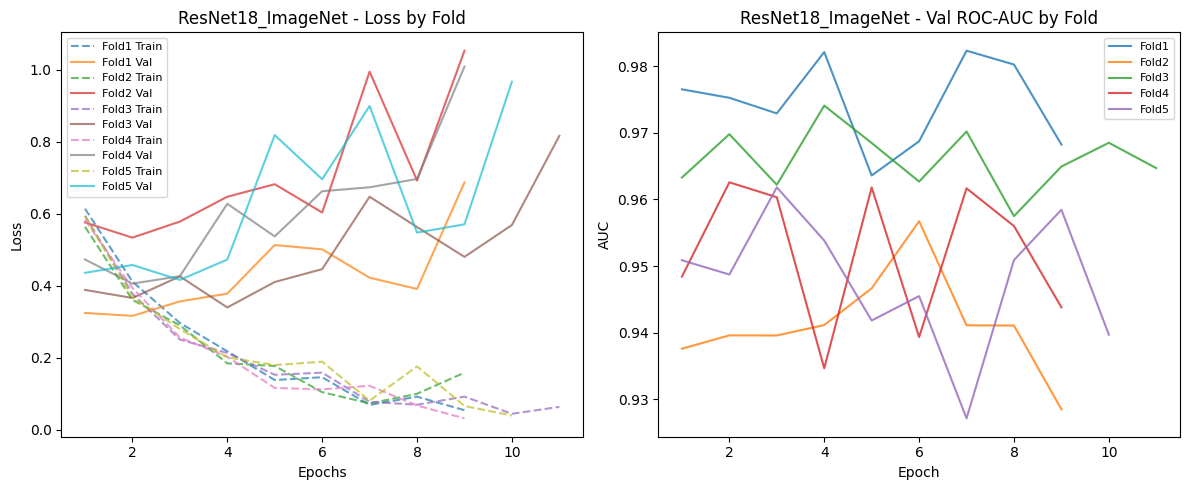

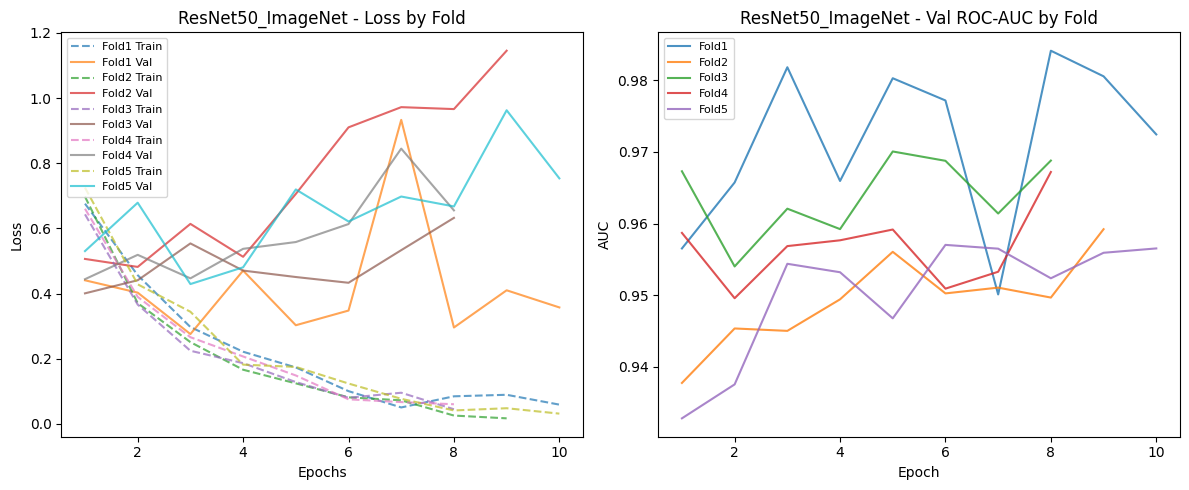

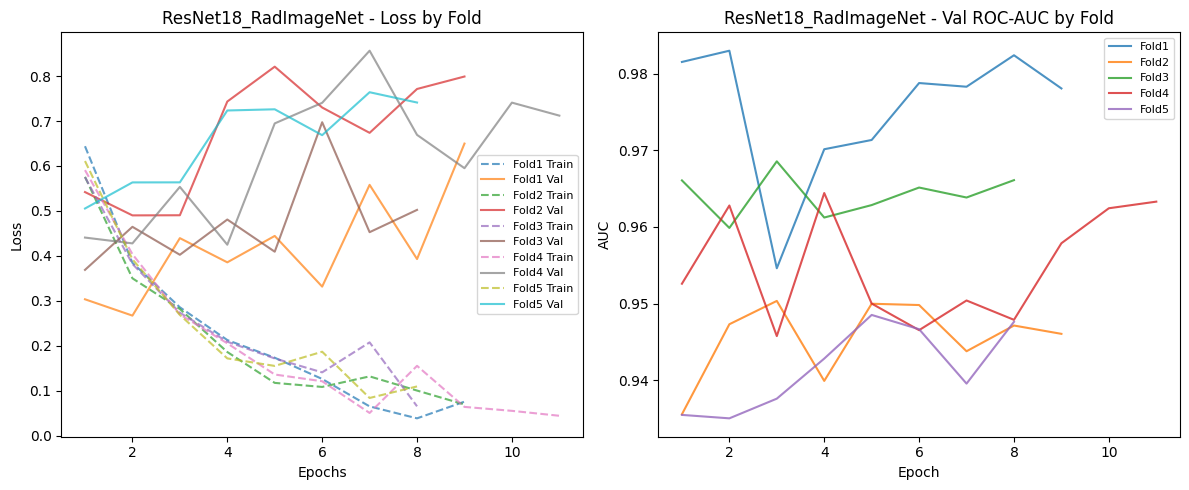

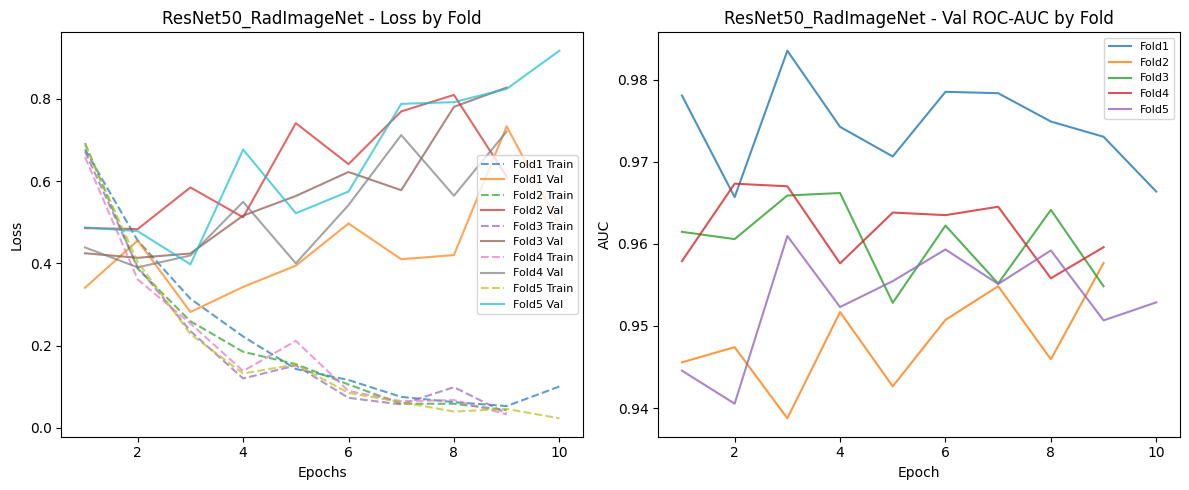

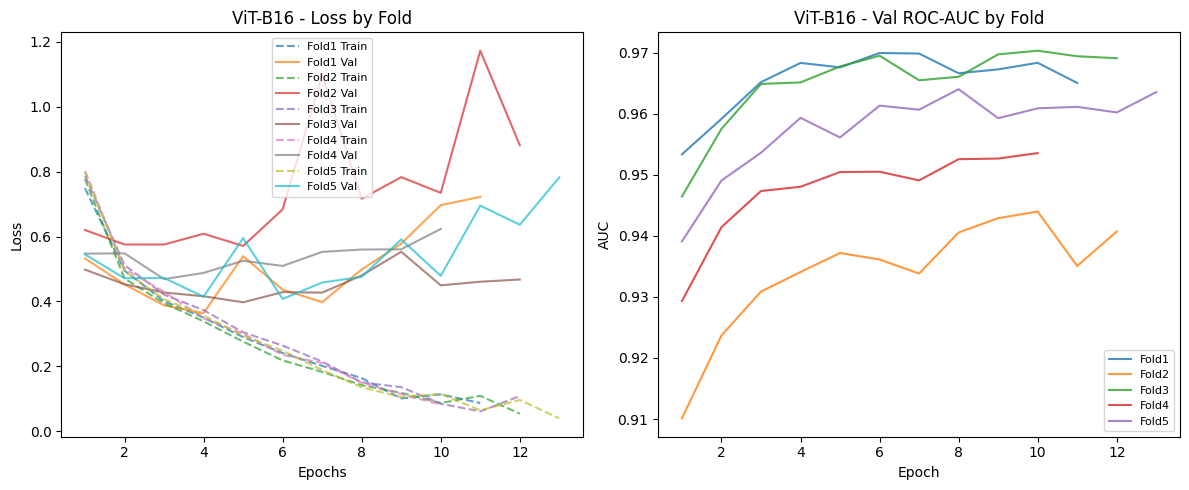

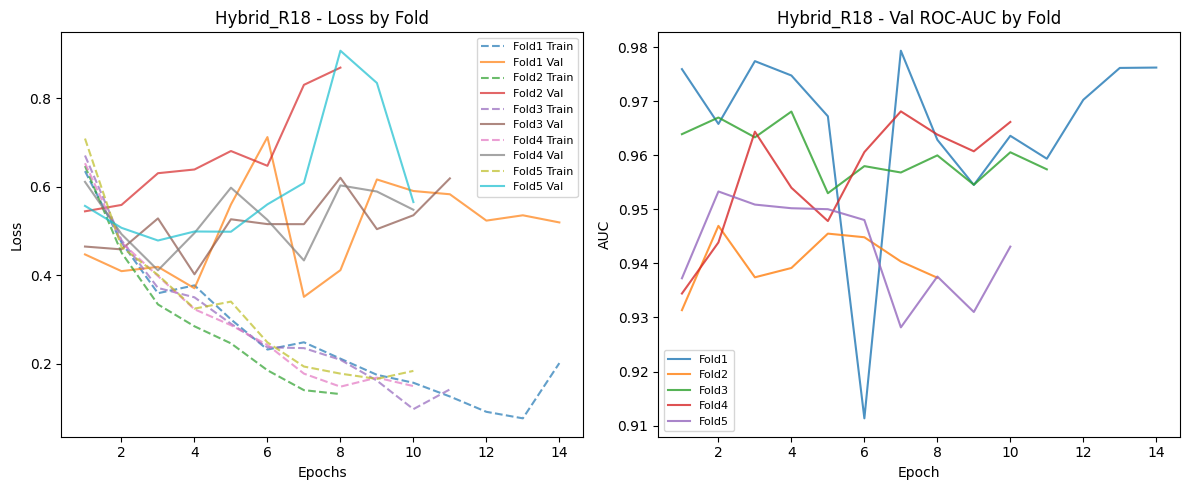

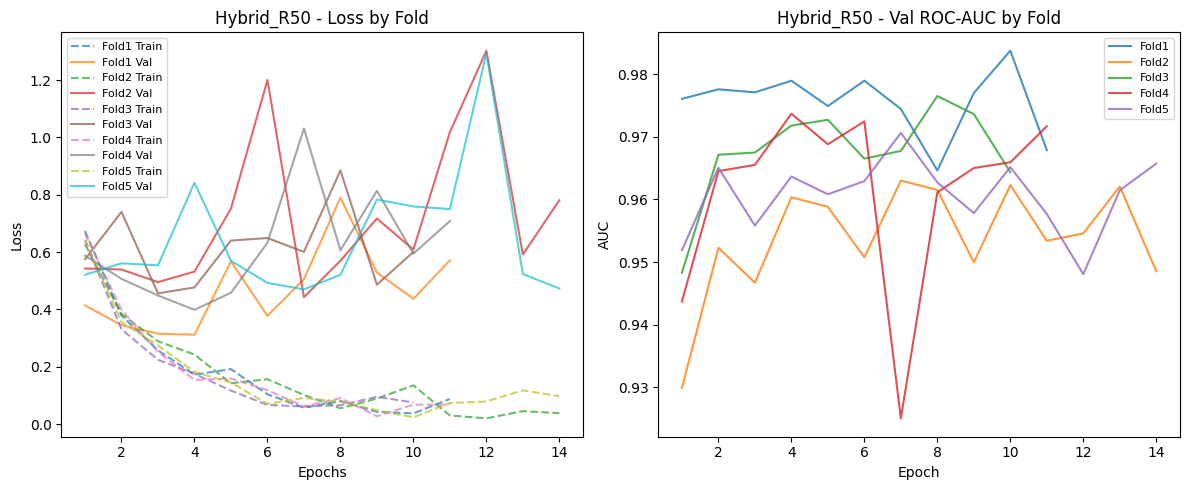

In [55]:
plot_one_model_by_fold(resnet18_imagenet_history_df, "ResNet18_ImageNet")
plot_one_model_by_fold(resnet50_imagenet_history_df, "ResNet50_ImageNet")
plot_one_model_by_fold(resnet18_rad_history_df, "ResNet18_RadImageNet")
plot_one_model_by_fold(resnet50_rad_history_df, "ResNet50_RadImageNet")
plot_one_model_by_fold(vit_history_df, "ViT-B16")
plot_one_model_by_fold(hybrid_r18_history_df, "Hybrid_R18")
plot_one_model_by_fold(hybrid_history_df, "Hybrid_R50")

In [59]:
def plot_roc_curve_paper(model_info_list, save_path=None):
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.50)')

    for info in model_info_list:
        fpr, tpr, _ = roc_curve(info["y_true"], info["y_prob"])
        auc_val = roc_auc_score(info["y_true"], info["y_prob"])
        ax.plot(fpr, tpr, lw=2, color=info["color"],
                label=f'{info["name"]} (AUC = {auc_val:.3f})')
        
    ax.set_xlabel("False Positive Rate", fontsize=13)
    ax.set_ylabel("True Positive Rate", fontsize=13)
    ax.set_title("ROC Curves - CT Binary Classification", fontsize=14, fontweight='bold')
    ax.legend(loc="lower right", fontsize=9, framealpha=0.9)
    ax.set_xli([0, 1])
    ax.set_ylim([0, 1.02])
    ax.grid(alpha=0.3)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"ROC curve saved -> {save_path}")
    plt.show()
    return fig

In [80]:
from sklearn.metrics import(
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score
)

def _to_1d_prob(y_prob):
    y_prob = np.asarray(y_prob)

    if y_prob.ndim == 1:
        return y_prob
    elif y_prob.ndim == 2 and y_prob.shape[1] ==2:
        return y_prob[:, 1]
    else:
        raise ValueError(
            f"y_prob shape이 이상"
        )
def plot_cv_roc_pr(
    fold_results,
    figsize=(6,6),
    roc_title="5-fold cv roc curve",
    save_roc_path=None,
    show_each_fold=True,
    ddof=1
):
    fold_aucs = []
    fold_aps = []

    all_y_true = []
    all_y_prob = []

    for i, fold in enumerate(fold_results, start=1):
        y_true=np.asarray(fold["y_true"]).astype(int)
        y_prob = _to_1d_prob(fold["y_prob"])

        if len(y_true) != len(y_prob):
            raise ValueError (f" {i}번째 fold: y_true y_prod 길이가 다름")
        if len(np.unique(y_true)) < 2:
            raise ValueError(f" {i}번째 fold: y_true에 클래스가 1개만")
        fold_auc = roc_auc_score(y_true, y_prob)
        fold_ap = average_precision_score(y_true, y_prob)

        fold_aucs.append(fold_auc)
        fold_aps.append(fold_ap)

        all_y_true.append(y_true)
        all_y_prob.append(y_prob)

    all_y_true = np.concatenate(all_y_true)
    all_y_prob = np.concatenate(all_y_prob)

    mean_auc = np.mean(fold_aucs)
    std_auc = np.std(fold_aucs)
    oof_auc = roc_auc_score(all_y_true, all_y_prob)

    plt.figure(figsize=figsize)
    
    if show_each_fold:
        for i, fold in enumerate(fold_results, start=1):
            y_true=np.asarray(fold["y_true"]).astype(int)
            y_prob = _to_1d_prob(fold["y_prob"])

            fpr, tpr, _ = roc_curve(y_true, y_prob)
            fold_auc = roc_auc_score(y_true, y_prob)

            plt.plot(
                fpr, tpr,
                alpha=0.35,
                label=f"Fold {i} (AUC={fold_auc:.4f})"
            )

    fpr_oof, tpr_oof, _ = roc_curve(all_y_true, all_y_prob)
    plt.plot(
        fpr_oof, tpr_oof,
        linewidth=2.5,
        label=f"OOF ROC (AUC={oof_auc:.4f})"
    )
    plt.plot([0,1], [0,1], linestyle="--", linewidth=1)

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{roc_title}\nMean AUC = {mean_auc:.4f} +- {std_auc:.4f}")
    plt.legend(loc="lower right", fontsize=9)
    plt.tight_layout()

    if save_roc_path is not None:
        plt.savefig(save_roc_path, dpi=150, bbox_inches="tight")

    plt.show()

    print("====5 fold cv roc summary === ")
    print("Fold AUCs:", [f"{x:.4f}" for x in fold_aucs])
    print(f"Mean AUC = {mean_auc:.4f} +- {std_auc:.4f}")
    print(f"OOF AUC = {oof_auc:.4f}")

    return {
        "fold_auc": fold_aucs,
        "mean_auc": mean_auc,
        "std_auc": std_auc,
        "oof_auc": oof_auc
    }


In [84]:
def plot_confusion_matrices_paper(model_info_list, save_path=None):
    n = len(model_info_list)
    ncols = 3
    nrows = (n + ncols -1) // ncols
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
    axes = axes.flatten()

    for i, info in enumerate(model_info_list):
        y_pred = (np.array(info["y_prob"]) > 0.5).astype(int)
        cm = confusion_matrix(info["y_true"], y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                      display_labels=["Benign", "Malignant"])
        disp.plot(ax=axes[i], colorbar=False, cmap="Blues")
        auc_val = roc_auc_score(info["y_true"], info["y_prob"])
        acc_val = accuracy_score(info["y_true"], y_pred)
        sens_val = recall_score(info["y_true"], y_pred, zero_division=0)
        axes[i].set_title(
            f'{info["name"]}\nACC={acc_val:.3f}  AUC={auc_val:.3f}  Sens={sens_val:.3f}',
            fontsize=10, fontweight='bold'
        )

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    fig.suptitle("Confusion Matrics - CT Binary Classification",
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Confusion matrix figure saved -> {save_path}")
    plt.show()
    return fig

In [62]:
def get_best_fold(cv_df):
    """ROC-AUC 기준 최고 fold 반환"""
    idx = cv_df["ROC-AUC"].idxmax()
    return int(cv_df.loc[idx, "fold"])

def collect_predictions_from_best(model_name, model_type, build_fn, best_fold, norm_type="imagenet"):
    _, val_loader, _ = make_fold_loaders(best_fold, norm_type=norm_type)
    best_path = OUTPUT_DIR / f"{model_name}_fold{best_fold}_best.pth"

    model = load_model(model_type, best_path, device)
    metrics = eval_confusion(model, val_loader, device, threshold=0.5)

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return metrics["y_true"], metrics["y_prob"], metrics

In [77]:
MODEL_REGISTRY = [
    dict(name="ResNet18\n(ImageNet)", model_name="ResNet18_ImageNet",
         model_type="resnet18_imagenet",
         build_fn=lambda: build_resnet18_patient_model(load_pretrained=False),
         cv_df=resnet50_imagenet_cv_df, color="#aec7e8", norm_type="imagenet"),
    dict(name="ResNet50\n(ImageNet)", model_name="ResNet50_ImageNet",
         model_type="resnet50_imagenet",
         build_fn=lambda: build_resnet50_patient_model(load_pretrained=False),
         cv_df=resnet50_imagenet_cv_df, color="#1f77b4", norm_type="imagenet"),
    dict(name="ResNet18\n(RadImageNet)", model_name="ResNet18_RadImageNet",
         model_type="resnet18_radimagenet",
         build_fn=lambda: build_resnet18_radimagenet_patient_model(load_pretrained=False),
         cv_df=resnet18_rad_cv_df, color="#2ca02c", norm_type="radimagenet"),
    dict(name="ResNet50\n(RadImageNet)", model_name="ResNet50_RadImageNet",
         model_type="resnet50_radimagenet",
         build_fn=lambda: build_resnet50_radimagenet_patient_model(load_pretrained=False),
         cv_df=resnet50_rad_cv_df, color="#ff7f0e", norm_type="radimagenet"),
    dict(name="ViT-B/16\n(ImageNet)", model_name="ViT-B16",
         model_type="vit",
         build_fn=lambda: build_vit_patient_model(load_pretrained=False),
         cv_df=vit_cv_df, color="#d62728", norm_type="imagenet"),
    dict(name="Hybrid\n(R18+ViT)", model_name="Hybrid_R18",
         model_type="hybrid_r18",
         build_fn=lambda: build_hybrid_r18_patient_model(load_pretrained=False),
         cv_df=hybrid_r18_cv_df, color="#8c564b", norm_type="imagenet"),
    dict(name="Hybrid\n(R50+ViT)", model_name="Hybrid_R50",
         model_type="hybrid_r50",
         build_fn=lambda: build_hybrid_patient_model(load_pretrained=False),
         cv_df=hybrid_cv_df, color="#9467bd", norm_type="imagenet"),
]


[ResNet18_ImageNet] Best fold = 1 | norm=imagenet
[FOLD 1] Train benign(0): 1605, malignant(1): 444, pos_weight=3.6149

--Final Evaluation (threshold=0.5) --
Accuracy: 0.9201
ROC-AUC : 0.9752
F1-score : 0.8353
Sensitivity : 0.9369
Confusion Matrix:
[[368  34]
 [  7 104]]

Classification report:
              precision    recall  f1-score   support

           0     0.9813    0.9154    0.9472       402
           1     0.7536    0.9369    0.8353       111

    accuracy                         0.9201       513
   macro avg     0.8675    0.9262    0.8913       513
weighted avg     0.9321    0.9201    0.9230       513

[FOLD 1] Train benign(0): 1605, malignant(1): 444, pos_weight=3.6149

--Final Evaluation (threshold=0.5) --
Accuracy: 0.9201
ROC-AUC : 0.9752
F1-score : 0.8353
Sensitivity : 0.9369
Confusion Matrix:
[[368  34]
 [  7 104]]

Classification report:
              precision    recall  f1-score   support

           0     0.9813    0.9154    0.9472       402
           1     0.75

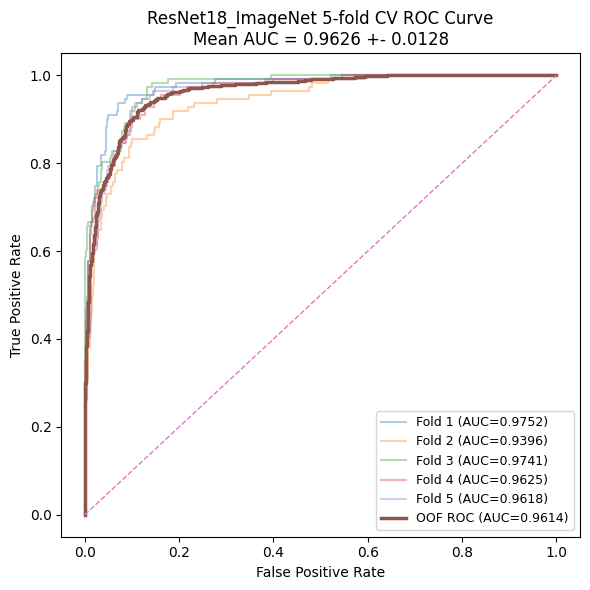

====5 fold cv roc summary === 
Fold AUCs: ['0.9752', '0.9396', '0.9741', '0.9625', '0.9618']
Mean AUC = 0.9626 +- 0.0128
OOF AUC = 0.9614


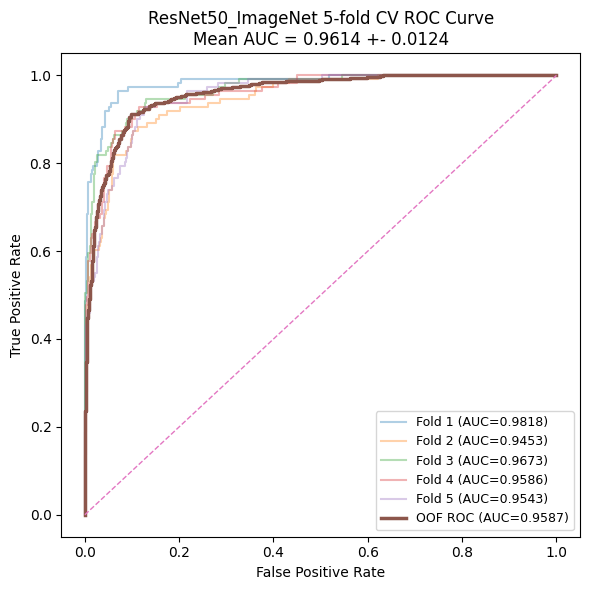

====5 fold cv roc summary === 
Fold AUCs: ['0.9818', '0.9453', '0.9673', '0.9586', '0.9543']
Mean AUC = 0.9614 +- 0.0124
OOF AUC = 0.9587


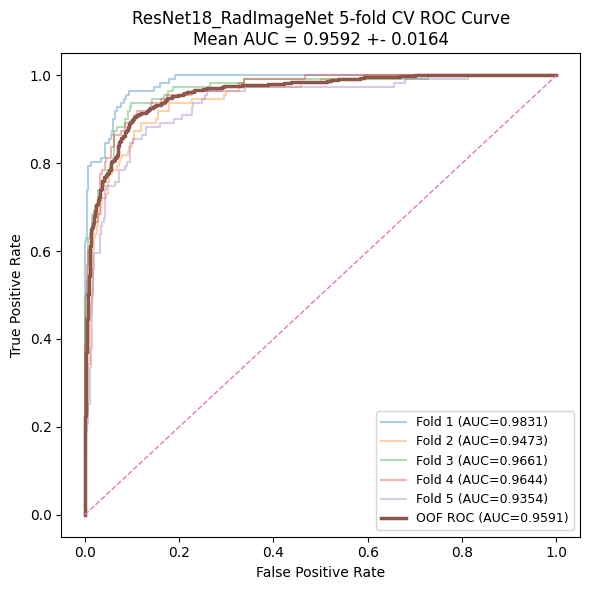

====5 fold cv roc summary === 
Fold AUCs: ['0.9831', '0.9473', '0.9661', '0.9644', '0.9354']
Mean AUC = 0.9592 +- 0.0164
OOF AUC = 0.9591


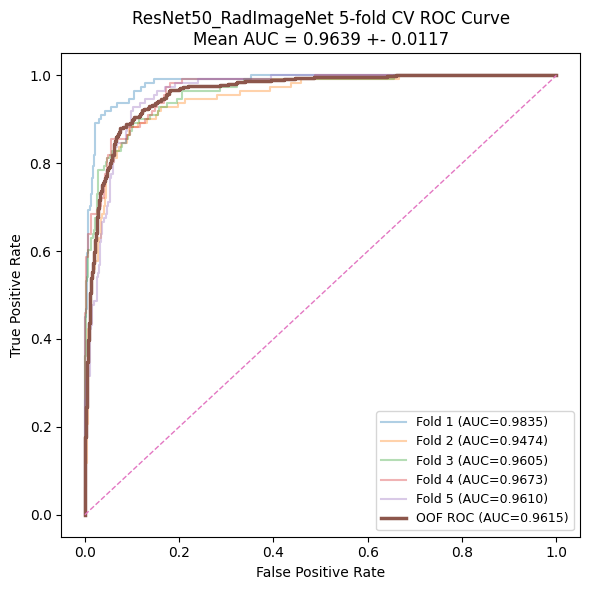

====5 fold cv roc summary === 
Fold AUCs: ['0.9835', '0.9474', '0.9605', '0.9673', '0.9610']
Mean AUC = 0.9639 +- 0.0117
OOF AUC = 0.9615


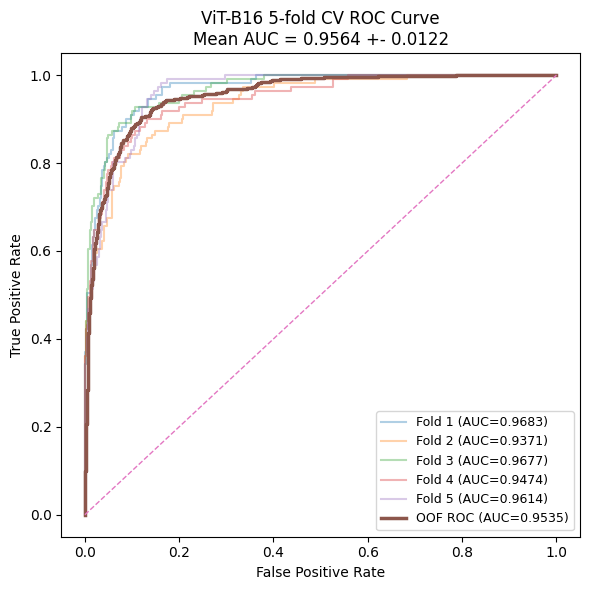

====5 fold cv roc summary === 
Fold AUCs: ['0.9683', '0.9371', '0.9677', '0.9474', '0.9614']
Mean AUC = 0.9564 +- 0.0122
OOF AUC = 0.9535


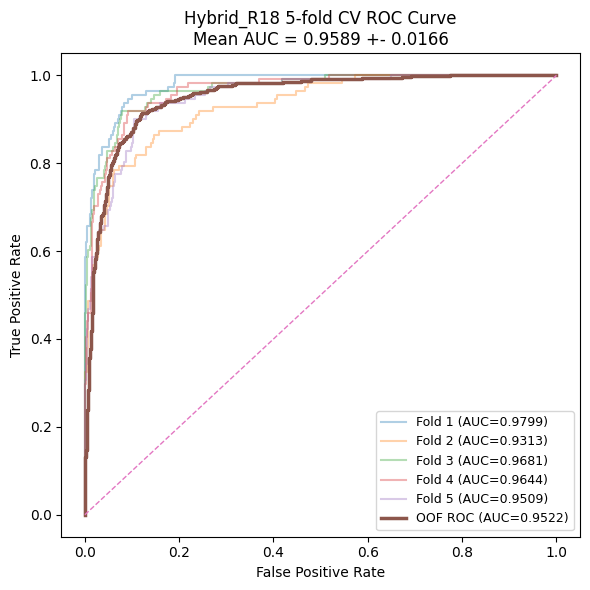

====5 fold cv roc summary === 
Fold AUCs: ['0.9799', '0.9313', '0.9681', '0.9644', '0.9509']
Mean AUC = 0.9589 +- 0.0166
OOF AUC = 0.9522


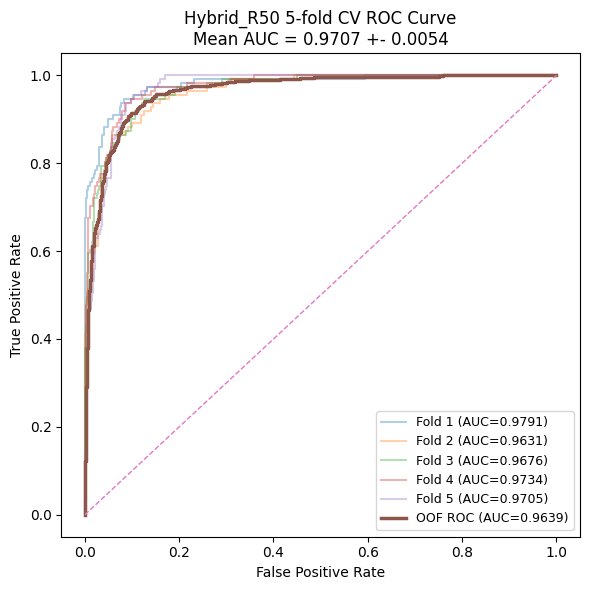

====5 fold cv roc summary === 
Fold AUCs: ['0.9791', '0.9631', '0.9676', '0.9734', '0.9705']
Mean AUC = 0.9707 +- 0.0054
OOF AUC = 0.9639


NameError: name 'nrows' is not defined

In [81]:
model_info_list = []
fold_results_per_model = {}

for entry in MODEL_REGISTRY:
    best_fold = get_best_fold(entry["cv_df"])
    print(f"\n[{entry['model_name']}] Best fold = {best_fold} | norm={entry['norm_type']}")

    y_true, y_prob, metrics = collect_predictions_from_best(
        model_name=entry["model_name"],
        model_type=entry["model_type"],
        build_fn=entry["build_fn"],
        best_fold=best_fold,
        norm_type=entry["norm_type"]
    )
    model_info_list.append({
        "name": entry["name"],
        "y_true": y_true,
        "y_prob": y_prob,
        "metrics": metrics,
        "color": entry["color"],
    })

    fold_results = []
    for fold_idx in FOLDS:
        _, vl, _ = make_fold_loaders(fold_idx, norm_type=entry["norm_type"])
        fp = OUTPUT_DIR / f"{entry['model_name']}_fold{fold_idx}_best.pth"
        m = load_model(entry["model_type"], fp, device)
        mt = eval_confusion(m, vl, device, threshold = 0.5)
        fold_results.append({"y_true": mt["y_true"], "y_prob": mt["y_prob"]})
        del m; gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    fold_results_per_model[entry["model_name"]] = fold_results

for entry in MODEL_REGISTRY:
    plot_cv_roc_pr(
        fold_results=fold_results_per_model[entry["model_name"]],
        roc_title=f"{entry['model_name']} 5-fold CV ROC Curve",
        save_roc_path=FIGURE_DIR / f"{entry['model_name']}_cv_roc.png",
        show_each_fold=True,
        ddof=1
    )


Confusion matrix figure saved -> ct_binary_figures/paper_confusion_matrices.png


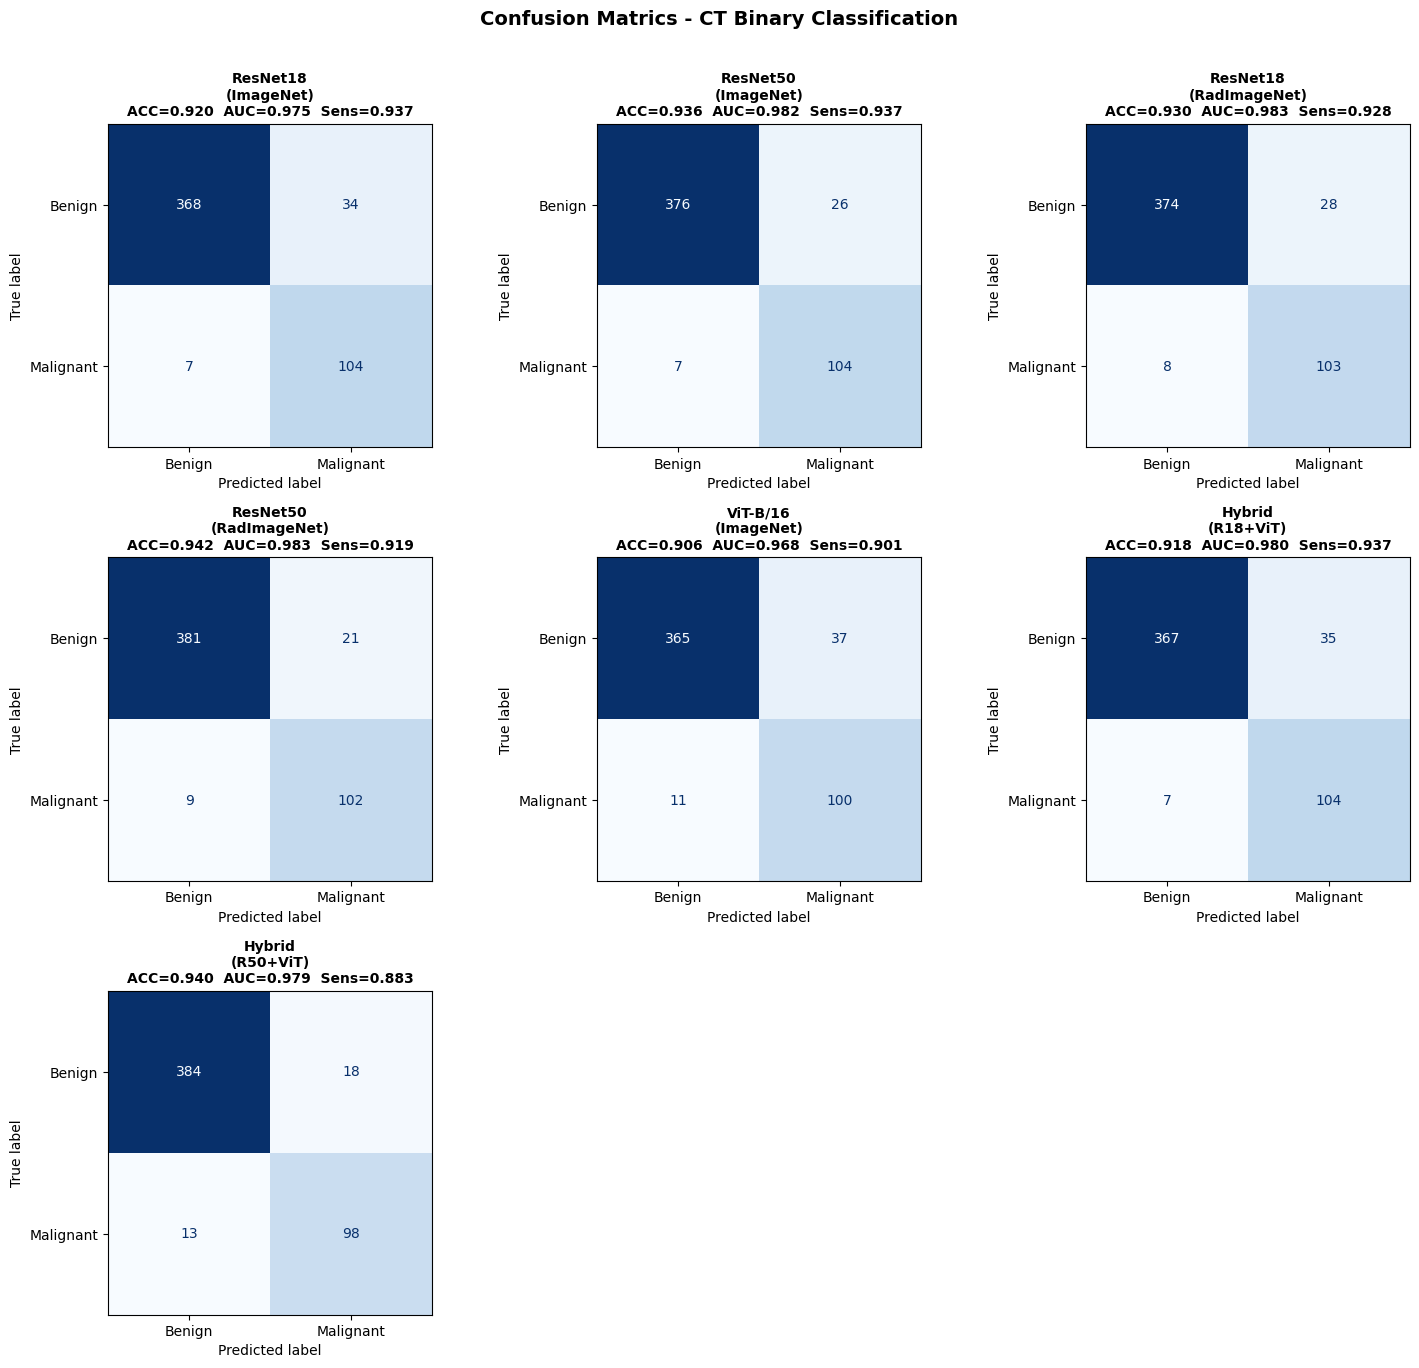


>>> All figures saved to: /tf/notebooks/Image Encoder/Untitled Folder/ct_binary_figures


In [85]:
cm_fig = plot_confusion_matrices_paper(
    model_info_list,
    save_path=FIGURE_DIR / "paper_confusion_matrices.png"
)

print("\n>>> All figures saved to:", FIGURE_DIR.resolve())